# TUGAS PRAKTIKUM 2

In [3]:
import threading
import time

class BankAccount:
    """Rekening bank sederhana. use_lock menentukan apakah operasi dilindungi Lock."""
    def __init__(self, saldo_awal=1_000_000):
        self.saldo = saldo_awal
        self.lock = threading.Lock()

    def _tarik(self):
        temp = self.saldo      # 1) BACA
        time.sleep(0)          # jeda kecil -> beri kesempatan thread lain berjalan
        temp -= 1              # 2) HITUNG
        self.saldo = temp      # 3) TULIS

    def _setor(self):
        temp = self.saldo
        time.sleep(0)
        temp += 1
        self.saldo = temp

    def tarik_setor(self, n_operasi=10_000, use_lock=False):
        for _ in range(n_operasi):
            if use_lock:
                with self.lock:
                    self._tarik()
                with self.lock:
                    self._setor()
            else:
                self._tarik()
                self._setor()


def jalankan_simulasi(use_lock, n_thread=10, n_operasi=10_000, saldo_awal=1_000_000):
    rekening = BankAccount(saldo_awal)
    threads = [
        threading.Thread(target=rekening.tarik_setor, args=(n_operasi, use_lock))
        for _ in range(n_thread)
    ]

    mulai = time.perf_counter()
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    selesai = time.perf_counter()

    return rekening.saldo, selesai - mulai

In [4]:
SALDO_AWAL = 1_000_000
N_THREAD = 10
N_OPERASI = 10_000

print(f"Saldo awal        : {SALDO_AWAL:,}")
print(f"Jumlah thread     : {N_THREAD}")
print(f"Operasi per thread: {N_OPERASI:,} (tarik 1, setor 1)")
print("-" * 55)

hasil_tanpa_lock = []
for percobaan in range(10):
    saldo_akhir, durasi = jalankan_simulasi(use_lock=False, n_thread=N_THREAD, n_operasi=N_OPERASI, saldo_awal=SALDO_AWAL)
    selisih = saldo_akhir - SALDO_AWAL
    hasil_tanpa_lock.append(saldo_akhir)
    status = "BENAR" if selisih == 0 else "SALAH (race condition!)"
    print(f"Percobaan {percobaan+1}: saldo akhir = {saldo_akhir:,} (selisih {selisih:+,}) -> {status} | waktu: {durasi:.3f}s")

Saldo awal        : 1,000,000
Jumlah thread     : 10
Operasi per thread: 10,000 (tarik 1, setor 1)
-------------------------------------------------------
Percobaan 1: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 0.983s
Percobaan 2: saldo akhir = 999,999 (selisih -1) -> SALAH (race condition!) | waktu: 1.398s
Percobaan 3: saldo akhir = 999,999 (selisih -1) -> SALAH (race condition!) | waktu: 0.596s
Percobaan 4: saldo akhir = 999,996 (selisih -4) -> SALAH (race condition!) | waktu: 0.574s
Percobaan 5: saldo akhir = 999,997 (selisih -3) -> SALAH (race condition!) | waktu: 0.609s
Percobaan 6: saldo akhir = 999,998 (selisih -2) -> SALAH (race condition!) | waktu: 0.634s
Percobaan 7: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 0.613s
Percobaan 8: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 0.707s
Percobaan 9: saldo akhir = 999,998 (selisih -2) -> SALAH (race condition!) | waktu: 0.652s
Percobaan 10: saldo akhir = 999,997 (selisih -3) -> SALAH (race condition!

In [5]:
hasil_dengan_lock = []
for percobaan in range(10):
    saldo_akhir, durasi = jalankan_simulasi(use_lock=True, n_thread=N_THREAD, n_operasi=N_OPERASI, saldo_awal=SALDO_AWAL)
    selisih = saldo_akhir - SALDO_AWAL
    hasil_dengan_lock.append(saldo_akhir)
    status = "BENAR" if selisih == 0 else "SALAH (race condition!)"
    print(f"Percobaan {percobaan+1}: saldo akhir = {saldo_akhir:,} (selisih {selisih:+,}) -> {status} | waktu: {durasi:.3f}s")

Percobaan 1: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 9.179s
Percobaan 2: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 1.923s
Percobaan 3: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 2.301s
Percobaan 4: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 2.414s
Percobaan 5: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 1.286s
Percobaan 6: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 1.994s
Percobaan 7: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 1.860s
Percobaan 8: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 2.574s
Percobaan 9: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 5.096s
Percobaan 10: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 8.688s


In [6]:
import threading
import queue
import time
import random

def producer(q, jumlah_item, jumlah_consumer, nama="Producer"):
    for i in range(jumlah_item):
        item = f"item-{i}"
        time.sleep(random.uniform(0.05, 0.2)) # Simulasi waktu produksi
        q.put(item)
        print(f"[{nama}] menghasilkan: {item}")
    
    # Kirim sinyal None ke setiap consumer agar semuanya bisa berhenti
    for _ in range(jumlah_consumer):
        q.put(None)

def consumer(q, nama="Consumer"):
    while True:
        item = q.get()
        
        # Cek jika menerima sinyal berhenti (None)
        if item is None:
            q.task_done()
            print(f"    [{nama}] menerima sinyal berhenti. Keluar...")
            break
        
        time.sleep(random.uniform(0.05, 0.15)) # Simulasi waktu pemrosesan
        print(f"    [{nama}] memproses: {item}")
        q.task_done()

# --- Program Utama ---
if __name__ == "__main__":
    q = queue.Queue()
    JUMLAH_CONSUMER = 3
    JUMLAH_ITEM = 6

    # Buat Thread Producer
    t_producer = threading.Thread(
        target=producer, 
        args=(q, JUMLAH_ITEM, JUMLAH_CONSUMER, "Producer-1")
    )

    # Buat 3 Thread Consumer
    consumers = []
    for i in range(1, JUMLAH_CONSUMER + 1):
        t = threading.Thread(
            target=consumer, 
            args=(q, f"Consumer-{i}")
        )
        consumers.append(t)

    # Jalankan semua thread
    t_producer.start()
    for c in consumers:
        c.start()
    # Tunggu semua thread selesai
    t_producer.join()
    for c in consumers:
        c.join()

    print("\nSemua item sudah diproduksi dan dikonsumsi. Program selesai.")

[Producer-1] menghasilkan: item-0
[Producer-1] menghasilkan: item-1
    [Consumer-1] memproses: item-0
[Producer-1] menghasilkan: item-2
    [Consumer-2] memproses: item-1
[Producer-1] menghasilkan: item-3
    [Consumer-3] memproses: item-2
[Producer-1] menghasilkan: item-4
    [Consumer-1] memproses: item-3
    [Consumer-2] memproses: item-4
[Producer-1] menghasilkan: item-5
    [Consumer-1] menerima sinyal berhenti. Keluar...
    [Consumer-2] menerima sinyal berhenti. Keluar...
    [Consumer-3] memproses: item-5
    [Consumer-3] menerima sinyal berhenti. Keluar...

Semua item sudah diproduksi dan dikonsumsi. Program selesai.


 SIMULASI PEMROSESAN 50 ITEM DENGAN MULTITHREADING
Max Workers     | Total Waktu (Detik)    | Kecepatan relatif
------------------------------------------------------------
2               | 2.4898                 | 1.0x (Baseline)
4               | 1.2074                 | 2.06x lebih cepat
8               | 0.6998                 | 3.56x lebih cepat
16              | 0.4088                 | 6.09x lebih cepat


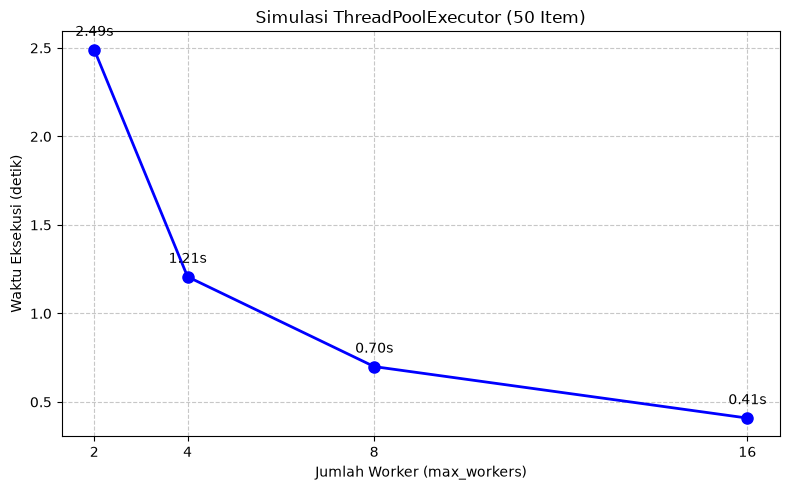

In [14]:
from concurrent.futures import ThreadPoolExecutor
import random
import time
import matplotlib.pyplot as plt


def process_item(item_id):
  processing_time = random.uniform(0.05, 0.15)
  time.sleep(processing_time)
  return f"Item-{item_id} selesai diproses"


def run_benchmark(workers, total_items=50):
  items = list(range(total_items))
  start_time = time.perf_counter()

  with ThreadPoolExecutor(max_workers=workers) as executor:
    results = list(executor.map(process_item, items))

  end_time = time.perf_counter()
  return end_time - start_time


if __name__ == "__main__":
  TOTAL_ITEMS = 50
  WORKER_CONFIGS = [2, 4, 8, 16]
  hasil_waktu = []  # List untuk menyimpan hasil waktu eksekusi

  print("=" * 60)
  print(f" SIMULASI PEMROSESAN {TOTAL_ITEMS} ITEM DENGAN MULTITHREADING")
  print("=" * 60)
  print(
      f"{'Max Workers':<15} | {'Total Waktu (Detik)':<22} |"
      f" {'Kecepatan relatif':<15}"
  )
  print("-" * 60)

  base_time = None

  for workers in WORKER_CONFIGS:
    elapsed = run_benchmark(workers, TOTAL_ITEMS)
    hasil_waktu.append(elapsed)  # Menyimpan waktu ke list

    if base_time is None:
      base_time = elapsed
      speedup = "1.0x (Baseline)"
    else:
      speedup = f"{base_time / elapsed:.2f}x lebih cepat"

    print(f"{workers:<15} | {elapsed:<22.4f} | {speedup:<15}")

  print("=" * 60)

  # --- PROSES MEMPLOT DIAGRAM GARIS ---
  plt.figure(figsize=(8, 5))
  plt.plot(
      WORKER_CONFIGS,
      hasil_waktu,
      marker="o",
      color="b",
      linestyle="-",
      linewidth=2,
      markersize=8,
  )

  plt.title(f"Simulasi ThreadPoolExecutor ({TOTAL_ITEMS} Item)")
  plt.xlabel("Jumlah Worker (max_workers)")
  plt.ylabel("Waktu Eksekusi (detik)")
  plt.xticks(WORKER_CONFIGS)
  plt.grid(True, linestyle="--", alpha=0.7)

  # Menambahkan label teks angka di atas setiap titik
  for x, y in zip(WORKER_CONFIGS, hasil_waktu):
    plt.annotate(
        f"{y:.2f}s",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
    )

  plt.tight_layout()
  plt.show()